In [37]:
import numpy as np
import re
import string
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [21]:
df = pd.read_csv('data/ED_triage.csv')
df

,triage_code,gender,age,admission_year,admission_month,admission_day,admission_weekday,admission_hour,kindref,ChiefComplaint,...,BlooddpressurSystol,BlooddpressurDiastol,PulseRate,RespiratoryRate,Temperature,O2Saturation,AVPU,TriageGrade,operational_patient,ref_specialist
0,13960101008,Female,77,2017,3,21,2,2,5,Z03.89,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,0,0
1,13960101009,Male,42,2017,3,21,2,2,6,T07,...,NaN,NaN,86.0,18.0,NaN,96.0,A,3,0,0
2,13960101010,Female,71,2017,3,21,2,2,6,R10.84,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0
3,13960101011,Male,77,2017,3,21,2,2,6,R53,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0
4,13960101012,Male,39,2017,3,21,2,2,6,T79.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143577,14001229114,Female,55,2022,3,20,0,23,3,K92.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0
143578,14001229115,Female,60,2022,3,20,0,23,6,T18.9,...,NaN,NaN,NaN,NaN,NaN,NaN,A,4,1,0
143579,14001229117,Female,70,2022,3,20,0,23,6,R55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0
143580,14001229118,Male,67,2022,3,20,0,23,6,K92.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0


In [23]:
df['NeedFastExecute'].unique()

array([2, 1, 0])

O dataset tem 143582 e 28 colunas


In [24]:
df['CriticalStatus'].unique()


array([ 0.,  1.,  2., nan])

In [27]:
df['StuporStatus'].unique()


array([ 0.,  2.,  1., nan])

In [29]:
df['PainGrade'].unique()


array([ 0.,  1.,  7.,  5.,  3.,  4.,  6., nan,  2.,  8.,  9., 10.])

In [33]:
df['Source'].unique()


array([ 0.,  2., nan,  1.])

In [34]:
df['TriageGrade'].unique()


array([5, 3, 2, 4, 1])

## Verificar desiquilibrio entre classes de Emergência de Triagem

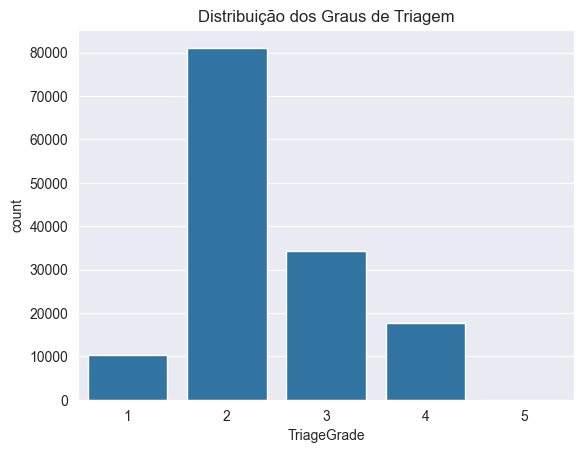

TriageGrade
2    0.564855
3    0.239334
4    0.123832
1    0.071847
5    0.000132
Name: proportion, dtype: float64


In [38]:
# Distribuição do Target
sns.countplot(x='TriageGrade', data=df)
plt.title('Distribuição dos Graus de Triagem')
plt.show()

print(df['TriageGrade'].value_counts(normalize=True))


In [51]:
# Filtrar apenas os graus 3 (Amarelo), 4 (Laranja) e 5 (Vermelho)
graus_urgentes = [2]
df_urgente = df[df['TriageGrade'].isin(graus_urgentes)]

# Calcular o total de pacientes por género no dataset completo
total_por_genero = df['gender'].value_counts()

# Calcular quantos de cada género receberam pulseiras 3, 4 ou 5
urgentes_por_genero = df_urgente['gender'].value_counts()

# Calcular a percentagem
percentagem_urgente = (urgentes_por_genero / total_por_genero) * 100

print("Percentagem de pacientes que recebem pulseira 3, 4 ou 5:")
print(percentagem_urgente)


Percentagem de pacientes que recebem pulseira 3, 4 ou 5:
gender
Male      55.281127
Female    58.477349
Name: count, dtype: float64


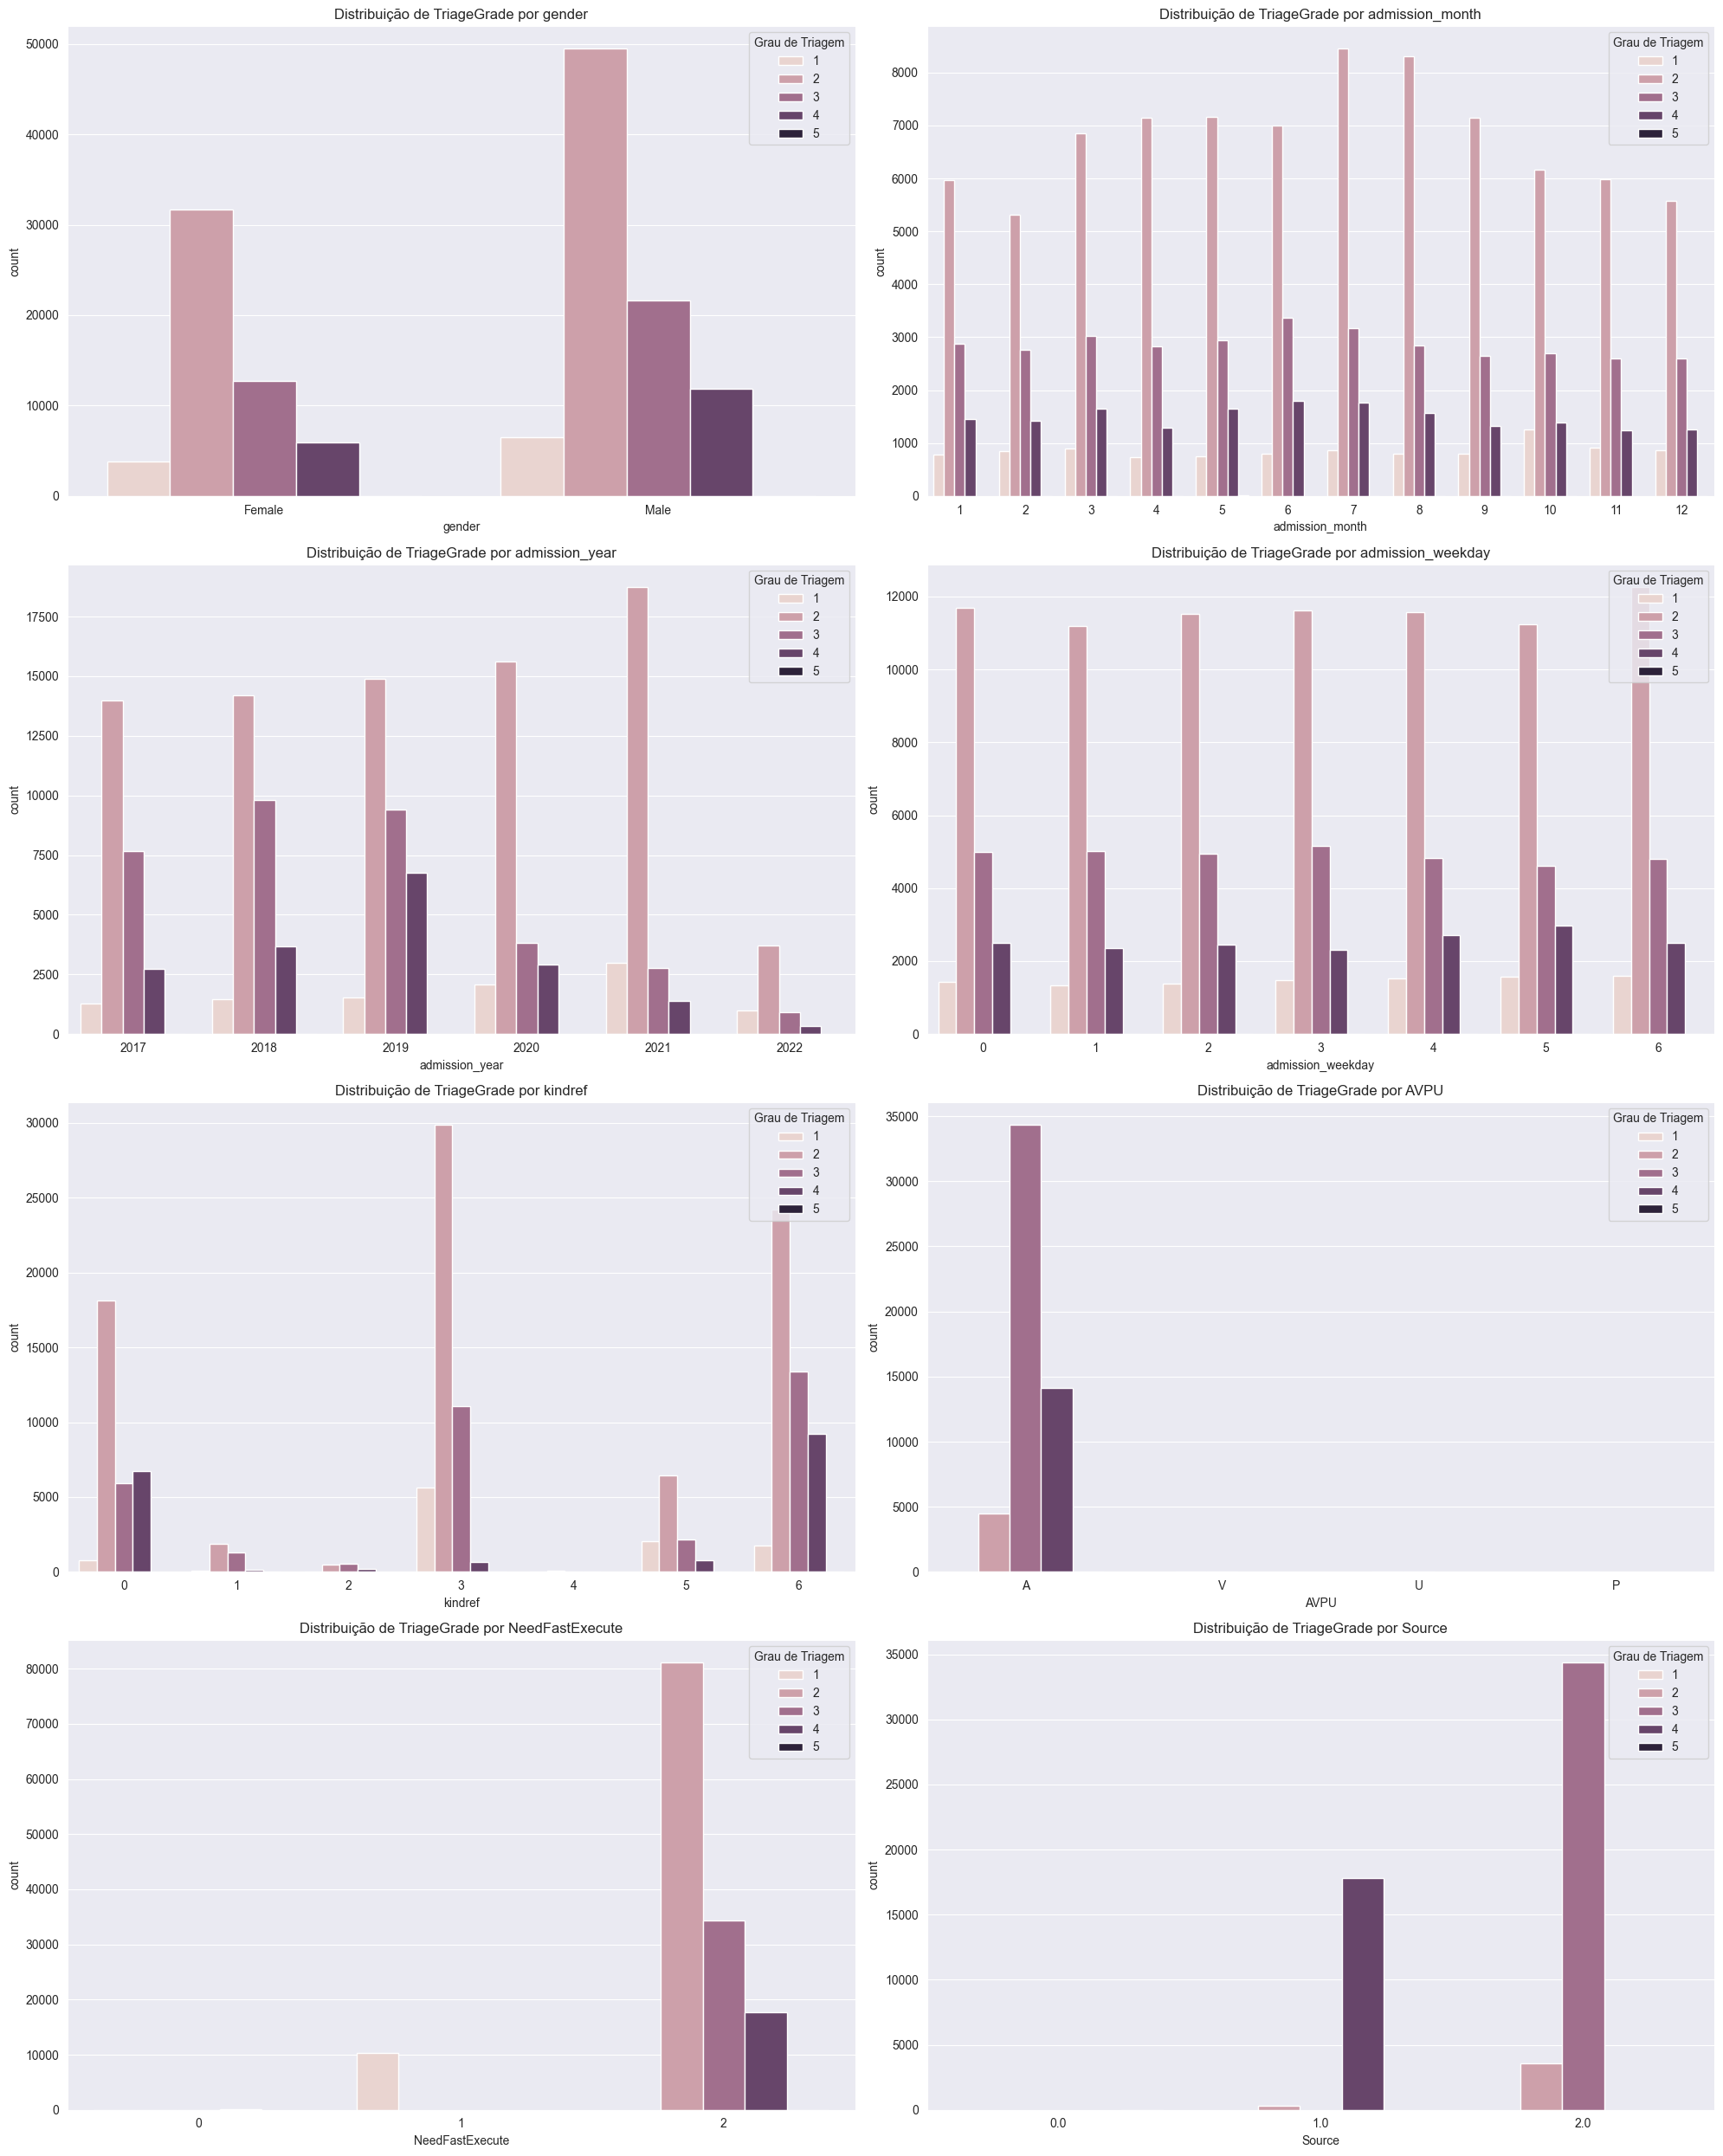

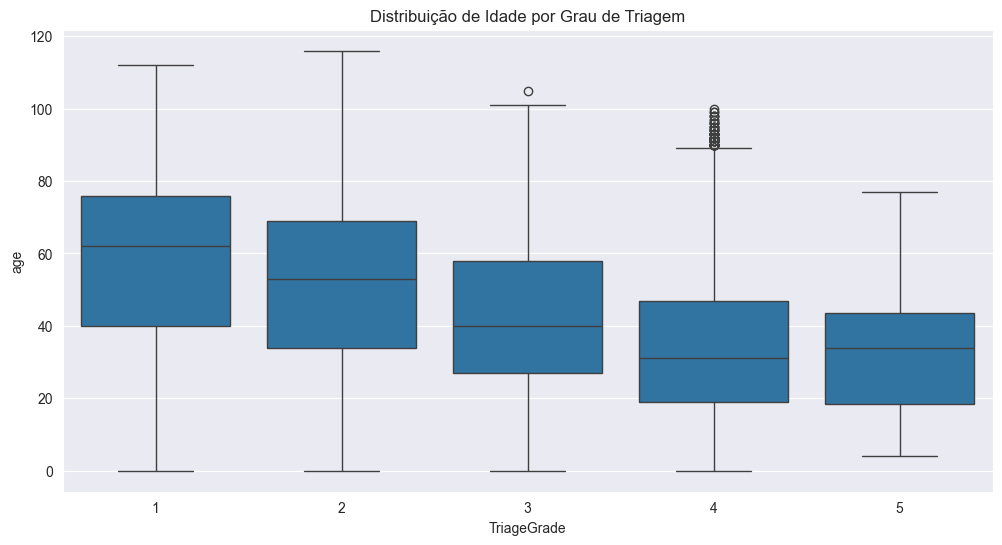

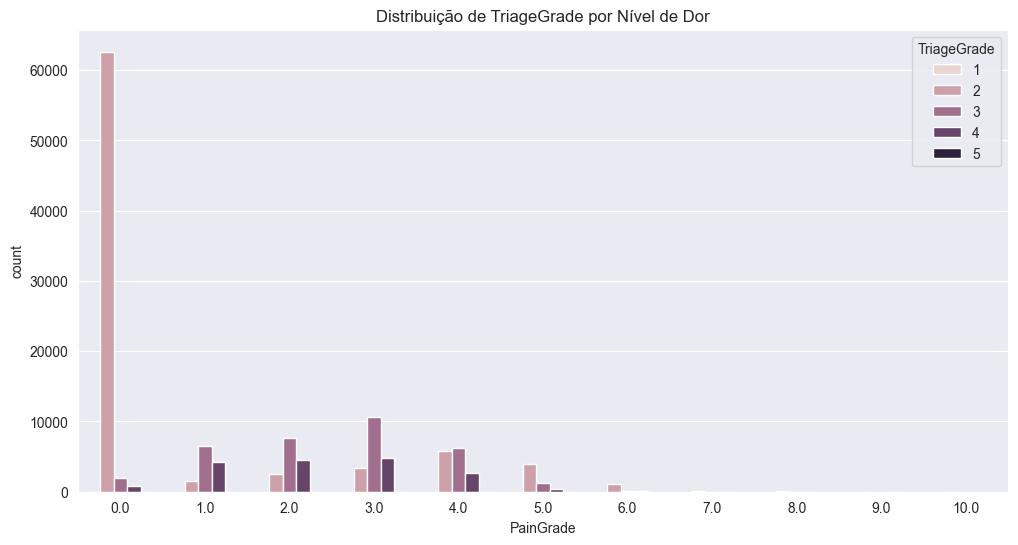

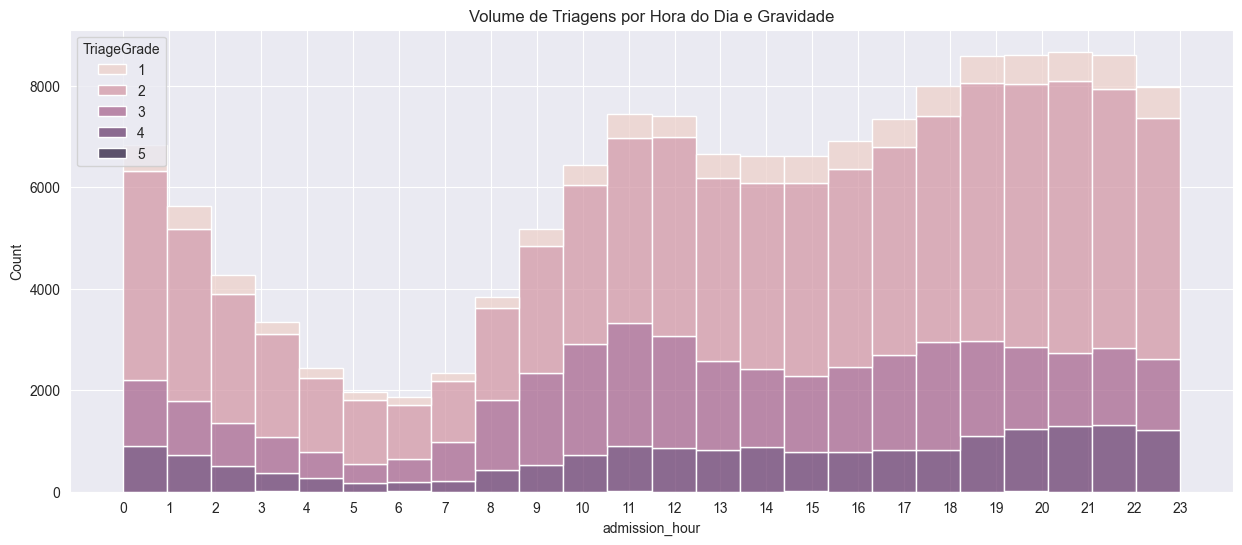

In [39]:
# Estas colunas têm valores fixos ou categorias
cols_categoricas = [
    'gender', 'admission_month', 'admission_year', 'admission_weekday',
    'kindref', 'AVPU', 'NeedFastExecute', 'Source'
]

plt.figure(figsize=(20, 25))
for i, col in enumerate(cols_categoricas, 1):
    plt.subplot(4, 2, i)
    # Usamos hue='TriageGrade' para ver a distribuição da gravidade dentro de cada categoria
    sns.countplot(data=df, x=col, hue='TriageGrade')
    plt.title(f'Distribuição de TriageGrade por {col}')
    plt.legend(title='Grau de Triagem', loc='upper right')

plt.tight_layout()
plt.show()

# 2. Variáveis Numéricas / Contínuas (Boxplots e Histogramas)
# Para idade, nível de dor e hora, queremos ver a dispersão e tendências

# Idade por TriageGrade
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='TriageGrade', y='age')
plt.title('Distribuição de Idade por Grau de Triagem')
plt.show()

# Nível de Dor (PainGrade)
plt.figure(figsize=(12, 6))
# Como PainGrade é de 0-10, podemos usar countplot ou boxplot
sns.countplot(data=df, x='PainGrade', hue='TriageGrade')
plt.title('Distribuição de TriageGrade por Nível de Dor')
plt.show()

# Hora de Admissão (Padrão de fluxo)
plt.figure(figsize=(15, 6))
sns.histplot(data=df, x='admission_hour', hue='TriageGrade', multiple="stack", bins=24)
plt.title('Volume de Triagens por Hora do Dia e Gravidade')
plt.xticks(range(0, 24))
plt.show()


In [59]:
df['NeedFastExecute'].value_counts()

NeedFastExecute
2    133201
1     10315
0        66
Name: count, dtype: int64

In [60]:
df['PainGrade'].value_counts()


PainGrade
0.0     65459
3.0     18850
4.0     14712
2.0     14673
1.0     12330
5.0      5635
6.0      1346
7.0       192
8.0        48
9.0        11
10.0       10
Name: count, dtype: int64